In [ ]:

from google.colab import files
files.upload()

Saving train_data.csv to train_data (1).csv


{'train_data (1).csv': b'age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income \r\n39, State-gov,77516, Bachelors,13, Never-married, Adm-clerical, Not-in-family, White, Male,2174,0,40, United-States, <=50K\r\n50, Self-emp-not-inc,83311, Bachelors,13, Married-civ-spouse, Exec-managerial, Husband, White, Male,0,0,13, United-States, <=50K\r\n38, Private,215646, HS-grad,9, Divorced, Handlers-cleaners, Not-in-family, White, Male,0,0,40, United-States, <=50K\r\n53, Private,234721, 11th,7, Married-civ-spouse, Handlers-cleaners, Husband, Black, Male,0,0,40, United-States, <=50K\r\n28, Private,338409, Bachelors,13, Married-civ-spouse, Prof-specialty, Wife, Black, Female,0,0,40, Cuba, <=50K\r\n37, Private,284582, Masters,14, Married-civ-spouse, Exec-managerial, Wife, White, Female,0,0,40, United-States, <=50K\r\n49, Private,160187, 9th,5, Married-spouse-absent, Other-service, Not-in-family, Blac

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [ ]:
df.shape

(32561, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:

df.replace("?", np.nan, inplace=True)
Mk
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


No missing values were found in the dataset, so there is no removal was required.

In [ ]:

df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

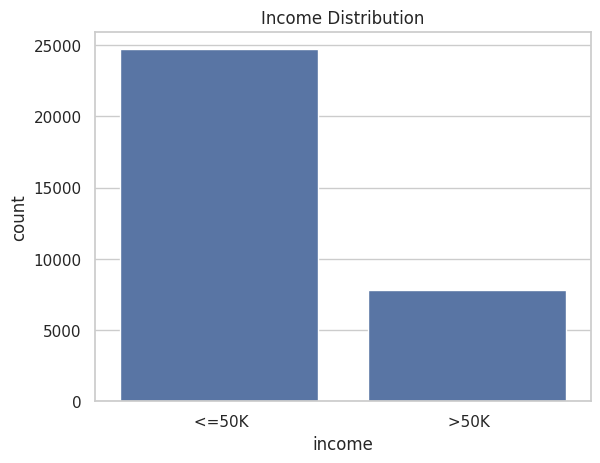

In [ ]:

sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()

Most people earn <=50K, so the dataset is imbalanced.

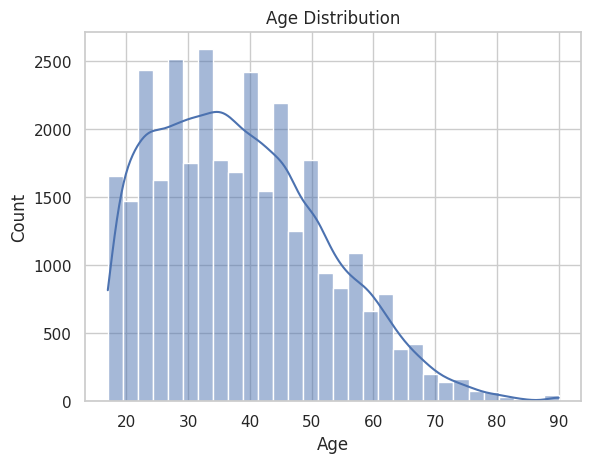

In [ ]:

sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Most people are between 20–50 years old.

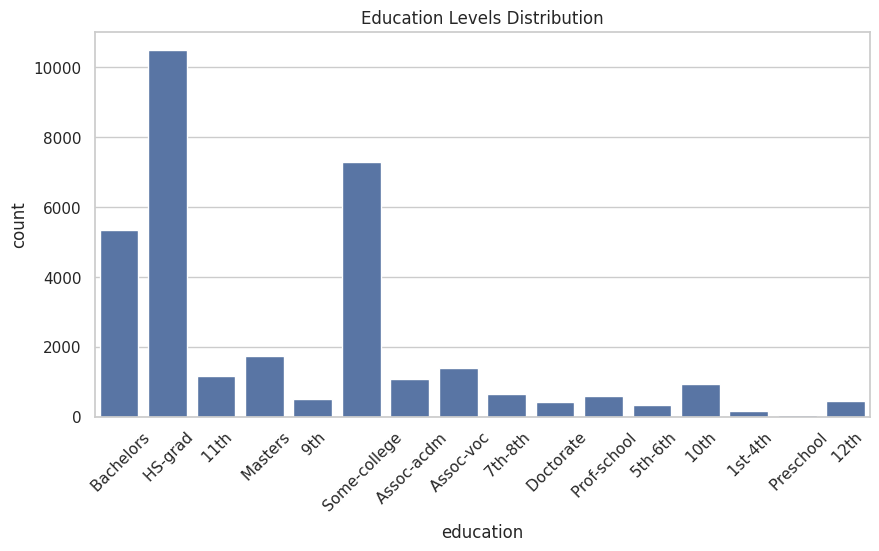

In [ ]:

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="education")
plt.xticks(rotation=45)
plt.title("Education Levels Distribution")
plt.show()

Most people have middle level education such as HS-grad or Some-college, while less people have higher or lower education levels

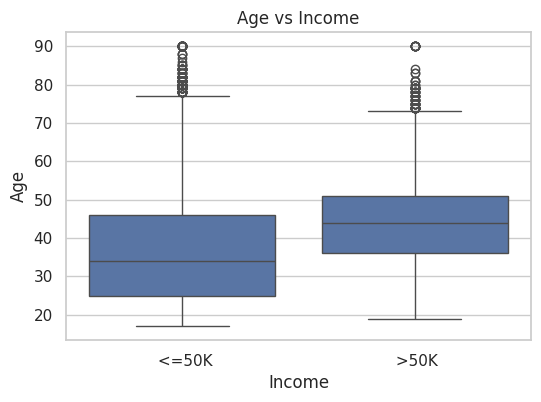

In [ ]:

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="income", y="age")
plt.title("Age vs Income")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

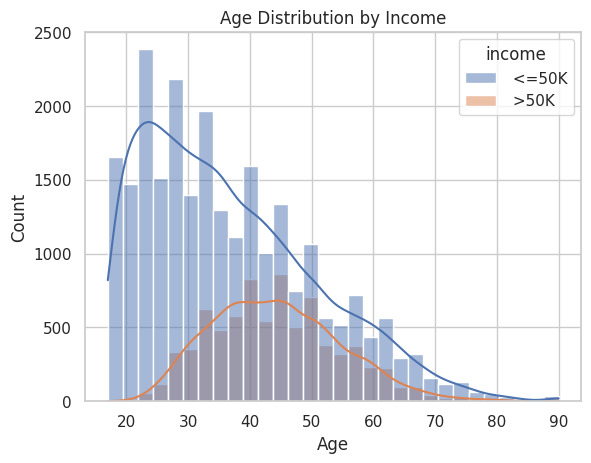

In [ ]:

sns.histplot(data=df, x="age", hue="income", bins=30, kde=True)
plt.title("Age Distribution by Income")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

People earning >50K are older on average compared to those earning ≤50K.

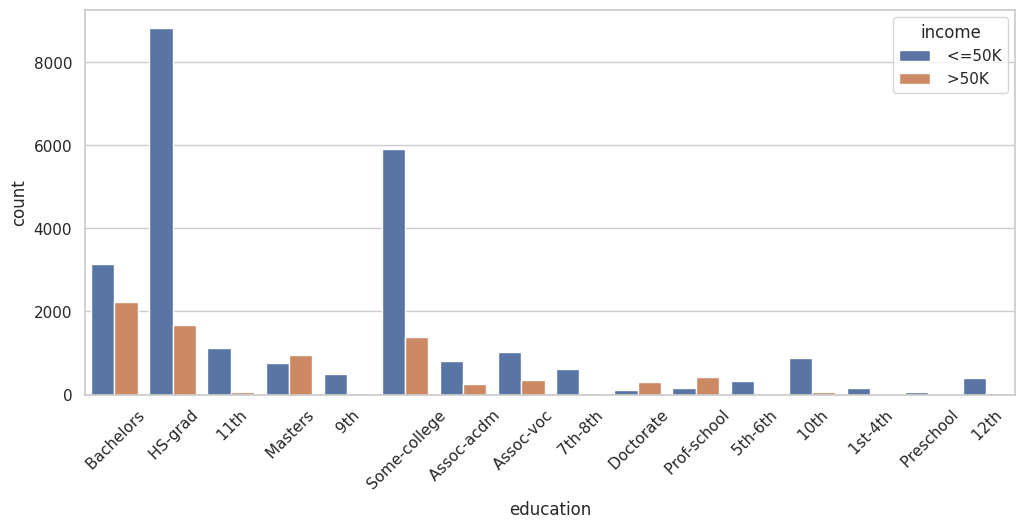

In [ ]:

plt.figure(figsize=(12,5))
sns.countplot(x="education", hue="income", data=df)
plt.xticks(rotation=45)
plt.show()

The higher the education level the higher the income.

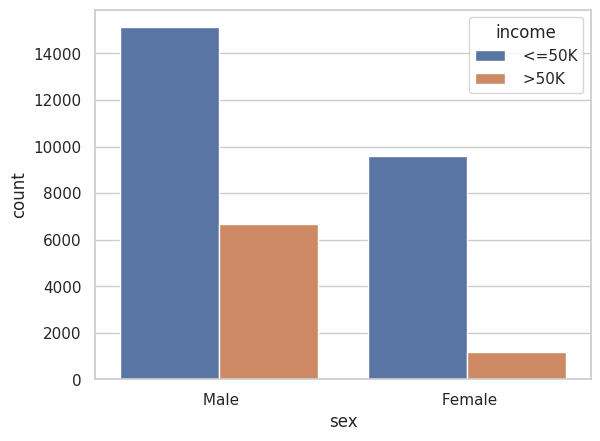

In [ ]:

sns.countplot(x="sex", hue="income", data=df)
plt.show()

Males have a higher proportion of >50K income compared to females.

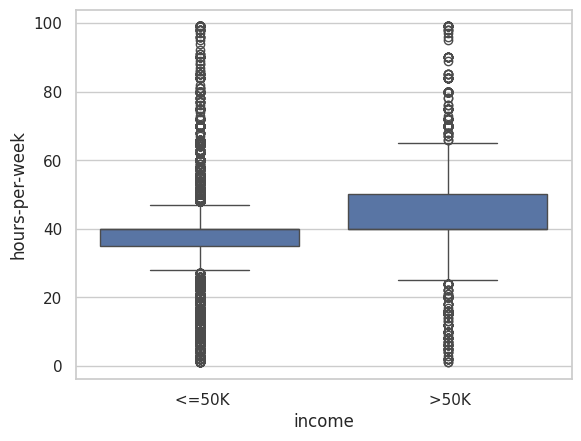

In [ ]:

sns.boxplot(x="income", y="hours-per-week", data=df)
plt.show()

People earning >50K tend to work more hours per week.

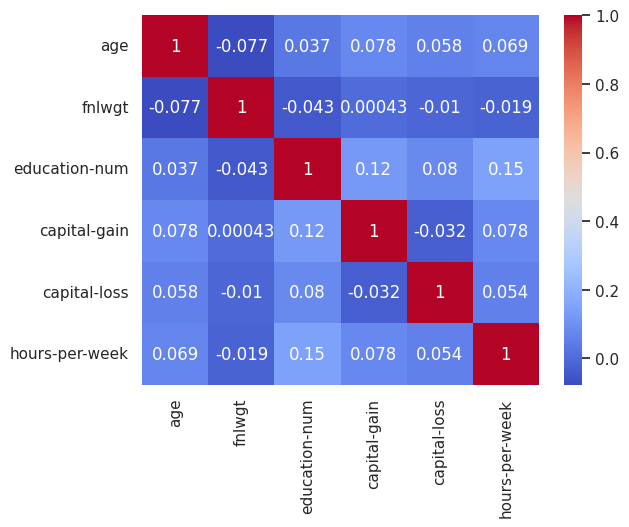

In [ ]:

num_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.show()

There are no very strong correlations between numerical features.

The dataset contains no missing values, Exploratory data analysis showed that education level, age, sex, and working hours influence income. Higher income is more common among older people, people with higher education, and people working more hours per week. Additionally, the dataset is imbalanced, as most people earn ≤50K. These factors are important for understanding income patterns and will be useful for building prediction models.